In [1]:
# Import modules
import numpy as np
from pathlib import Path
import os
from os import chdir
import xgcm
import gsw
import pandas as pd
from scipy.stats import linregress
import re
from datetime import datetime
import glob

# Maps and figures
from matplotlib.ticker import MultipleLocator, FuncFormatter
import matplotlib.ticker as ticker
import matplotlib.pyplot as plt
import matplotlib as mpl
import matplotlib.cm as cm
import cmocean

In [2]:
ECCO_version = 'v4r4'
#ECCO_version = 'v4r5'

In [23]:
df = pd.read_csv(f'N2_D_COM_depths_ECCO{ECCO_version}.csv',index_col=None,parse_dates=["time"])
df_volume = pd.read_csv(f'volumes_per_depth_ECCO{ECCO_version}.csv',index_col=None)

In [24]:
df = df.set_index(['time','depth'])

In [25]:
list_depth = df.index.get_level_values("depth").unique().to_numpy()
list_times = df.index.get_level_values("time").unique().tolist()

In [26]:
import numpy as np
import pandas as pd
from scipy.stats import kendalltau

# df: rows indexed by MultiIndex ('time','depth'); columns are numeric variables

SECS_PER_YEAR = 365.25 * 24 * 3600.0

def _kendalltau_pvalue(t, y):
    res = kendalltau(t, y)
    return res.pvalue

def _regress_tc(t, y):
    """
    OLS for y ~ m*t + b with per-column NaN handling.
    Returns: slope, intercept, stderr_fit, stderr_slope
      - stderr_fit: residual std error = sqrt(SSE/(n-2))
      - stderr_slope: std error of slope from covariance matrix
    """
    mask = ~np.isnan(y)
    n = mask.sum()
    if n < 3:
        return np.nan, np.nan, np.nan, np.nan

    tc = t[mask]
    yc = y[mask]

    # Design matrix [t, 1]
    X = np.c_[tc, np.ones_like(tc)]
    # Solve least squares
    beta, *_ = np.linalg.lstsq(X, yc, rcond=None)
    slope, intercept = beta

    # Residuals and residual variance
    yhat = X @ beta
    resid = yc - yhat
    sse = float((resid**2).sum())
    dof = n - 2
    if dof <= 0:
        return slope, intercept, np.nan, np.nan
    sigma2 = sse / dof

    # (X'X)^(-1) for standard errors
    XtX = X.T @ X
    try:
        XtX_inv = np.linalg.inv(XtX)
    except np.linalg.LinAlgError:
        # perfectly collinear t (e.g., all identical times)
        return np.nan, np.nan, np.nan, np.nan

    var_slope = sigma2 * XtX_inv[0, 0]
    stderr_fit = np.sqrt(sigma2)
    stderr_slope = np.sqrt(var_slope) if var_slope >= 0 else np.nan

    return slope, intercept, stderr_fit, stderr_slope


def _compute_stats(df_in: pd.DataFrame, timescale: str) -> pd.DataFrame:
    assert isinstance(df_in.index, pd.MultiIndex)
    time = df_in.index.get_level_values("time")
    t_sec = time.view("i8") / 1e9
    t_sec_mean = np.nanmean(t_sec)  # keep global center

    rows = []
    for depth_val, g in df_in.groupby(level="depth", sort=True):
        # >>> FIX: build t from the group’s own time level (not idx.codes)
        t_g = g.index.get_level_values("time").view("i8") / 1e9
        t_g = t_g - t_sec_mean
        means = g.mean(axis=0, skipna=True)
        stds = g.std(axis=0, skipna=True)

        for col in g.columns:
            y = g[col].to_numpy()
            slope_sec, intercept, stderr_fit, stderr_slope_sec = _regress_tc(t_g, y)
            slope_year = slope_sec * SECS_PER_YEAR if np.isfinite(slope_sec) else np.nan
            stderr_slope_year = stderr_slope_sec * SECS_PER_YEAR if np.isfinite(stderr_slope_sec) else np.nan
            time_mean = float(means[col]) if pd.notna(means[col]) else np.nan
            time_std = float(stds[col]) if pd.notna(stds[col]) else np.nan
            rel_change = (slope_year / time_mean * 100.0) if (np.isfinite(slope_year) and pd.notna(time_mean) and time_mean != 0) else np.nan
            rel_stderr = (stderr_fit / time_mean * 100.0) if (np.isfinite(stderr_fit) and pd.notna(time_mean) and time_mean != 0) else np.nan
            rel_stderr_slope = (stderr_slope_year / time_mean * 100.0) if (np.isfinite(stderr_slope_year) and pd.notna(time_mean) and time_mean != 0) else np.nan
            kendalltau_pvalue = _kendalltau_pvalue(t_g, y)

            rows.append({
                "timescale": timescale,
                "depth": depth_val,
                "variable": col,
                "time_mean": time_mean,
                "time_std": time_std,
                "slope_per_year": slope_year,
                "stderr_linear_fit": stderr_fit,
                "stderr_slope_per_year": stderr_slope_year,
                "rel_change": rel_change,
                "rel_stderr": rel_stderr,
                "rel_stderr_slope_per_year": rel_stderr_slope,
                "kendalltau_pvalue": kendalltau_pvalue
            })
    return pd.DataFrame(rows)

def stats_per_depth(df: pd.DataFrame) -> pd.DataFrame:
    # monthly stats
    monthly = _compute_stats(df, timescale="monthly")

    # annual-mean series (Jan–Dec); change freq='A' to 'AS-JUL' etc. if needed
    df_year = df.groupby([pd.Grouper(level="time", freq="YE"), "depth"]).mean()
    annual = _compute_stats(df_year, timescale="annual")

    out = pd.concat([monthly, annual], ignore_index=True)
    return out.set_index(["timescale", "depth", "variable"]).sort_index()


In [27]:
trends_df = stats_per_depth(df)
trends_monthly_df = trends_df.xs('monthly',level=0)
trends_annual_df  = trends_df.xs('annual',level=0)

In [28]:
plot_df = pd.DataFrame(index=list_depth)

In [37]:
plot_df['mean_depth'] = df_volume.set_index('depth').mean_depth

In [38]:
n2_cols = trends_monthly_df.xs('N2_mean',level=1)
com_cols = trends_monthly_df.xs('CoM',level=1)

In [39]:
plot_df['N2_mean'] = n2_cols["time_mean"].values
plot_df['CoM_mean'] = com_cols["time_mean"].values

plot_df['N2_std'] = n2_cols["time_std"].values
plot_df['CoM_std'] = com_cols["time_std"].values

plot_df['N2_trend'] = n2_cols['slope_per_year'].values
plot_df['CoM_trend'] = com_cols['slope_per_year'].values

plot_df['N2_SE'] = n2_cols["stderr_slope_per_year"].values
plot_df['CoM_SE'] = com_cols["stderr_slope_per_year"].values

plot_df['N2_RC'] = n2_cols["rel_change"].values
plot_df['CoM_RC'] = com_cols["rel_change"].values

plot_df['N2_RC_SE'] = n2_cols["rel_stderr_slope_per_year"].values
plot_df['CoM_RC_SE'] = com_cols["rel_stderr_slope_per_year"].values

plot_df['N2_tau_pvalue'] = n2_cols["kendalltau_pvalue"].values
plot_df['CoM_tau_pvalue'] = com_cols["kendalltau_pvalue"].values

In [41]:
def interp_profiles(df: pd.DataFrame, depth_interp):
    """
    df: DataFrame with numeric depth as index and properties as columns.
    depth_interp: list like [200, 500, 2000, 'max_depth']
    """
    # Ensure unique, sorted numeric index
    df = df[~df.index.duplicated(keep='first')].sort_index()

    # Replace 'max_depth' with the actual max depth value
    depths = [
        (df.index.max() if (isinstance(d, str) and d.lower() == "max_depth") else d)
        for d in depth_interp
    ]

    # Reindex to include requested depths, then interpolate along the index
    new_index = np.unique(np.concatenate([df.index.values, np.array(depths, dtype=float)]))
    interpolated = (
        df.reindex(new_index)
          .interpolate(method="index")     # linear in index space
          # If you want linear extrapolation outside the data range, use:
          # .interpolate(method="index", limit_direction="both")
          .loc[depths]
    )

    # Keep the requested order
    interpolated.index = depth_interp
    return interpolated

depth_interp = [200, 500, 1000, 2000, 'max_depth']
plot_df_interp = interp_profiles(plot_df, depth_interp)


In [42]:
plot_df_interp

,mean_depth,N2_mean,CoM_mean,N2_std,CoM_std,N2_trend,CoM_trend,N2_SE,CoM_SE,N2_RC,CoM_RC,N2_RC_SE,CoM_RC_SE,N2_tau_pvalue,CoM_tau_pvalue
200,192.671422,0.000091,0.035248,2.361470e-06,0.001079,3.569703e-08,0.000010,1.772052e-08,0.000008,0.039484,0.028676,0.019495,0.023206,1.269531e-01,3.760849e-01
500,471.181734,0.000051,0.102893,9.337810e-07,0.001561,4.932264e-08,0.000133,6.474379e-09,0.000009,0.097409,0.129492,0.012770,0.008793,3.417370e-11,2.930116e-25
1000,923.949396,0.000030,0.190809,4.878053e-07,0.002450,2.857509e-08,0.000279,3.308841e-09,0.000010,0.095422,0.146078,0.011051,0.005045,3.194948e-14,3.235601e-68
2000,1802.553933,0.000017,0.353219,2.514730e-07,0.003237,1.523812e-08,0.000388,1.691341e-09,0.000011,0.089313,0.109877,0.009913,0.003002,3.721901e-15,2.659410e-83
max_depth,3857.107768,0.000008,0.688679,1.188538e-07,0.005216,7.499465e-09,0.000658,7.905064e-10,0.000013,0.089900,0.095500,0.009476,0.001825,2.485852e-16,5.382342e-101


In [43]:
rows = plot_df_interp.index
summary = pd.DataFrame(index=rows)

for metric in ["CoM", "N2", ]:
    mean_vals = plot_df_interp.loc[rows, f"{metric}_mean"]
    trend_vals = plot_df_interp.loc[rows, f"{metric}_trend"]
    rel_trend = plot_df_interp.loc[rows, f"{metric}_RC"]
    se_vals = plot_df_interp.loc[rows, f"{metric}_RC_SE"]

    if metric == "N2":
        summary[(metric, "mean [10^{-5} s⁻²]")] = (mean_vals*1e5).round(2)
        summary[(metric, "trend [10^{-8} s⁻² yr⁻¹]")] = (trend_vals*1e8).round(2)
        summary[(metric, "rel_trend [% yr⁻¹]")] = rel_trend.round(2)
        summary[(metric, "SE [% yr⁻¹]")] = se_vals.round(3)

    elif metric == "CoM":
        summary[(metric, "mean [cm]")] = (mean_vals*1e2).round(2)
        summary[(metric, "trend [mm yr⁻¹]")] = (trend_vals*1e3).round(2)
        summary[(metric, "rel_trend [% yr⁻¹]")] = rel_trend.round(2)
        summary[(metric, "SE [% yr⁻¹]")] = se_vals.round(3)

summary.columns = pd.MultiIndex.from_tuples(summary.columns, names=["Metric", "Value"])

In [44]:
summary

Metric          CoM                                                 \
Value     mean [cm] trend [mm yr⁻¹] rel_trend [% yr⁻¹] SE [% yr⁻¹]   
200            3.52            0.01               0.03       0.023   
500           10.29            0.13               0.13       0.009   
1000          19.08            0.28               0.15       0.005   
2000          35.32            0.39               0.11       0.003   
max_depth     68.87            0.66               0.10       0.002   

Metric                    N2                                              \
Value     mean [10^{-5} s⁻²] trend [10^{-8} s⁻² yr⁻¹] rel_trend [% yr⁻¹]   
200                     9.08                     3.57               0.04   
500                     5.07                     4.93               0.10   
1000                    2.99                     2.86               0.10   
2000                    1.71                     1.52               0.09   
max_depth               0.83                     0.75               0.09   

Metric                 
Value     SE [% yr⁻¹]  
200             0.019  
500             0.013  
1000            0.011  
2000            0.010  
max_depth       0.009

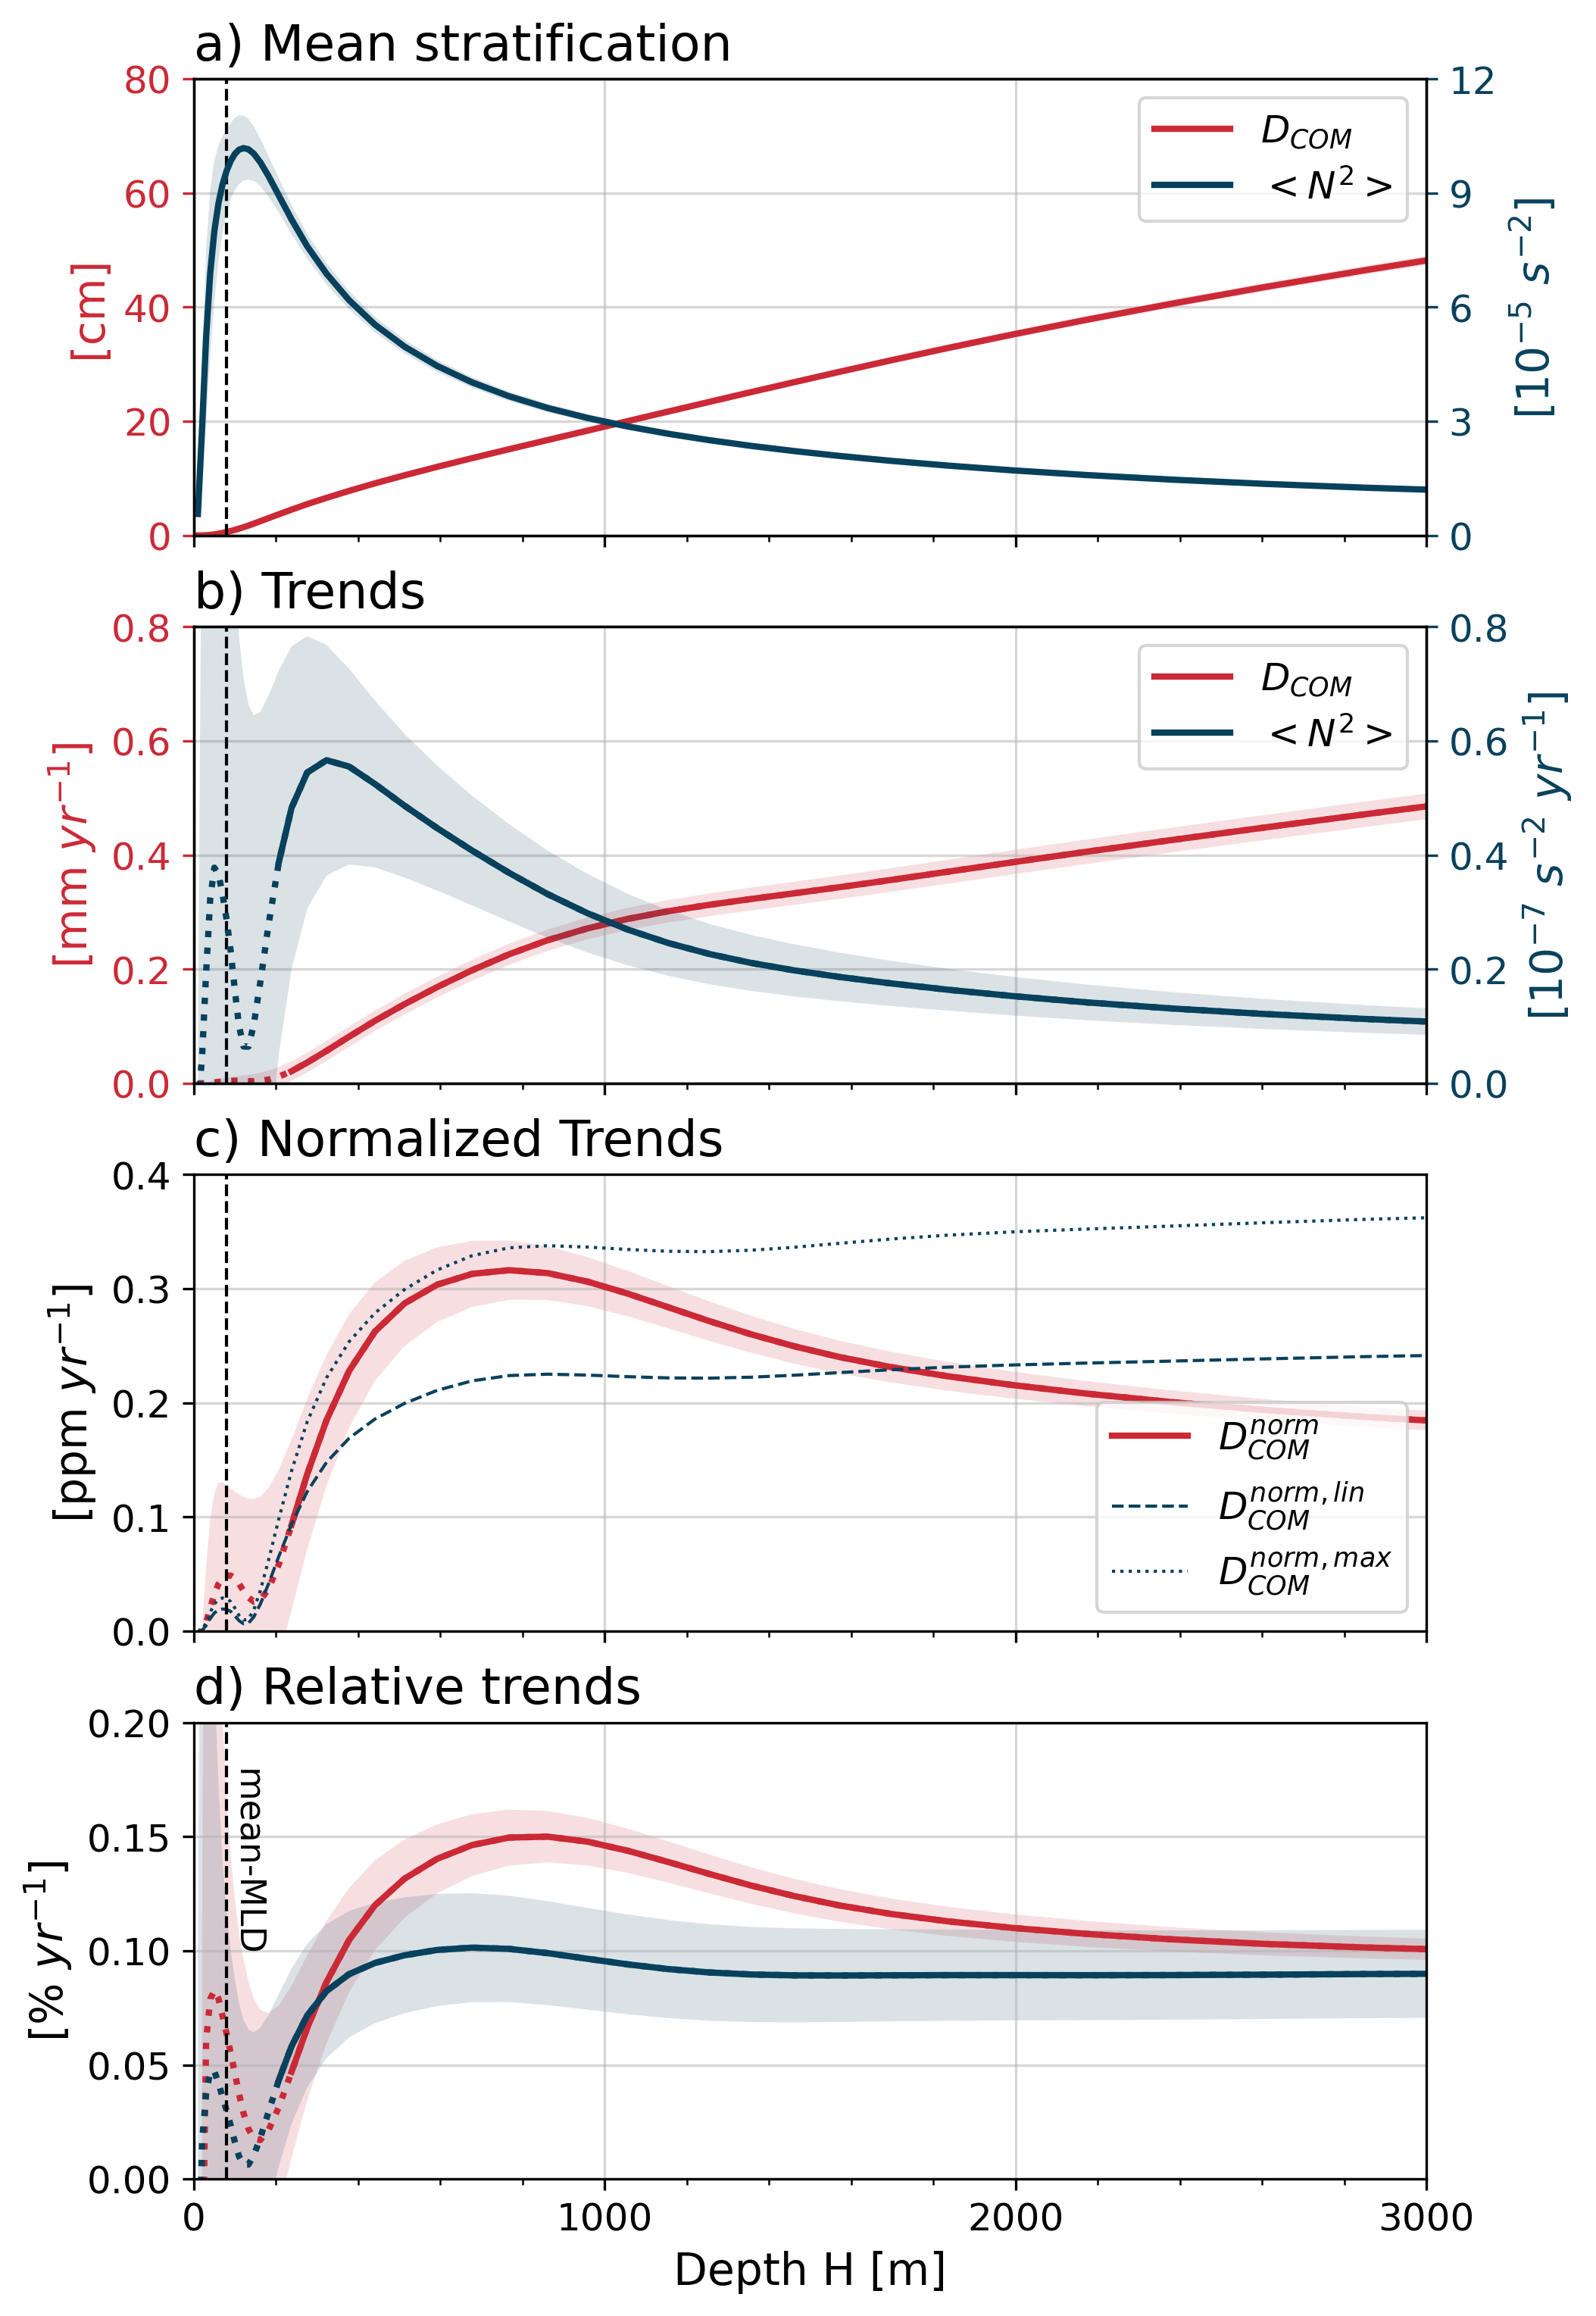

In [53]:
plt.rcParams.update({
    "font.size": 12,
    "font.family": "sans-serif",
    "axes.labelsize": 14,
    "axes.titlesize": 14,
    "legend.fontsize": 12,
    "xtick.labelsize": 12,
    "ytick.labelsize": 12
})

fig, axes = plt.subplots(4, 1, figsize=(7, 12), dpi=300, sharex=True)

# -------------------
# 1st subplot
ax1 = axes[0]
ax2 = ax1.twinx()

line1, = ax1.plot(plot_df.index, (plot_df.CoM_mean*100), color='#CC2936', linewidth=2,
                  label=r'$D_{COM}$')
# line2, = ax1.plot(plot_df.index, (plot_df.N2_mean*plot_df.index**2/12/9.81*100), color='#CC2936',
#                   linewidth=2, linestyle='--',
#                   label=r'$D_{COM}^{lin.strat.}$')
line3, = ax2.plot(plot_df.index, plot_df.N2_mean*1e5, color='#08415C', linewidth=2,
                  label=r'$<N^2>$')
ax1.fill_between(plot_df.index, (plot_df.CoM_mean - plot_df.CoM_std*2)*100, (plot_df.CoM_mean + plot_df.CoM_std*2)*100, alpha=0.15, color= '#CC2936', linewidth=0)
ax2.fill_between(plot_df.index, (plot_df.N2_mean - plot_df.N2_std*2)*1e5, (plot_df.N2_mean + plot_df.N2_std*2)*1e5, alpha=0.15, color= '#08415C', linewidth=0)

ax1.set_ylabel("[cm]", color='#CC2936')
ax2.set_ylabel(r"[$10^{-5}$" " " r"$s^{-2}$]", color='#08415C')
ax1.set_title('a) Mean stratification', loc='left', fontsize=16)

ax1.tick_params(axis='y', color='#CC2936', labelcolor='#CC2936')
ax2.tick_params(axis='y', color='#08415C', labelcolor='#08415C')

lines = [line1, line3]
labels = [l.get_label() for l in lines]

ax1.legend(
    lines, labels,
    loc="upper right",
    frameon=True,
    fancybox=True,
    framealpha=0.8
)

ax1.grid(linestyle='-', alpha=0.5)

ax1.axvline(78.94319, color='k', linestyle='--', linewidth=1)

ax1.set_ylim(0, 80)
ax2.set_ylim(0, 12)
ax2.set_yticks(ax1.get_yticks()*12/80)

# -------------------
# 2nd subplot
ax1 = axes[1]
ax2 = ax1.twinx()

line1b, = ax1.plot(plot_df.index, (plot_df.CoM_trend*1e3), color='#CC2936', linewidth=2, linestyle=':',
                  label='_nolegend_')
line1, = ax1.plot(plot_df.index, (plot_df.CoM_trend.where(plot_df.CoM_tau_pvalue <= .1)*1e3), color='#CC2936', linewidth=2,
                  label=r'$D_{COM}$')
# line2, = ax1.plot(plot_df.index, (plot_df.N2_trend*plot_df.index**2/12/9.81*1000), color='#CC2936',
#                   linewidth=2, linestyle='--', label=r'$D_{COM}^{lin.strat.}$')
line3b, = ax2.plot(plot_df.index, plot_df.N2_trend*1e7, color='#08415C', linewidth=2, linestyle=':',
                  label='_nolegend_')
line3, = ax2.plot(plot_df.index, plot_df.N2_trend.where(plot_df.N2_tau_pvalue <= .1)*1e7, color='#08415C', linewidth=2,
                  label=r'$<N^2>$')
ax1.fill_between(plot_df.index, (plot_df.CoM_trend - plot_df.CoM_SE*2)*1e3, (plot_df.CoM_trend + plot_df.CoM_SE*2)*1e3, alpha=0.15, color= '#CC2936', linewidth=0)
ax2.fill_between(plot_df.index, (plot_df.N2_trend - plot_df.N2_SE*2)*1e7, (plot_df.N2_trend + plot_df.N2_SE*2)*1e7, alpha=0.15, color='#08415C', linewidth=0)


ax1.set_ylabel("[mm " r"$yr^{-1}$]", color='#CC2936')
ax2.set_ylabel(r"[$10^{-7}$" " " r"$s^{-2}$" " " r"$yr^{-1}$]", color='#08415C')
ax1.set_title('b) Trends', loc='left', fontsize=16)

ax1.tick_params(axis='y', color='#CC2936', labelcolor='#CC2936')
ax2.tick_params(axis='y', color='#08415C', labelcolor='#08415C')

lines = [line1, line3]
labels = [l.get_label() for l in lines]
ax1.legend(lines, labels, loc="upper right", frameon=True, fancybox=True, framealpha=0.8)
ax1.grid(linestyle='-', alpha=0.5)

ax1.axvline(78.94319, color='k', linestyle='--', linewidth=1)

ax1.set_ylim(0,.8)
ax2.set_ylim(0,.8)
ax2.set_yticks(ax1.get_yticks())

# -------------------
# 3rd subplot
ax1 = axes[2]

line1b, = ax1.plot(plot_df.index, (plot_df.CoM_trend/plot_df.mean_depth*1e6), color='#CC2936', linewidth=2, linestyle=':',
                  label='_nolegend_')
line1, = ax1.plot(plot_df.index, (plot_df.CoM_trend/plot_df.mean_depth*1e6).where(plot_df.CoM_tau_pvalue <= .1), color='#CC2936', linewidth=2,
                  label=r'$D_{COM}^{norm}$')
line2, = ax1.plot(plot_df.index, (plot_df.N2_trend*plot_df.mean_depth/12/9.81*1e6), color='#08415C', linewidth=1,
                  label=r'$D_{COM}^{norm,lin}$',linestyle='--')
line3, = ax1.plot(plot_df.index, (plot_df.N2_trend*plot_df.mean_depth/8/9.81*1e6), color='#08415C', linewidth=1,
                  label=r'$D_{COM}^{norm,max}$',linestyle=':')
ax1.fill_between(plot_df.index, (plot_df.CoM_trend - plot_df.CoM_SE*2)/plot_df.mean_depth*1e6, (plot_df.CoM_trend + plot_df.CoM_SE*2)/plot_df.mean_depth*1e6, alpha=0.15, color= '#CC2936', linewidth=0)


ax1.set_ylabel("[ppm " r"$yr^{-1}$]")
ax1.set_title('c) Normalized Trends', loc='left', fontsize=16)

ax1.tick_params(axis='y', color='k', labelcolor='k')

lines = [line1, line2, line3]
labels = [l.get_label() for l in lines]
ax1.legend(
    lines, labels,
    loc="lower right",
    frameon=True,
    fancybox=True,
    framealpha=0.8
)
ax1.grid(linestyle='-', alpha=0.5)
ax1.axvline(78.94319, color='k', linestyle='--', linewidth=1)

ax1.set_ylim(0,.4)


# -------------------
# 4rd subplot
ax = axes[3]
ax.plot(plot_df.index, plot_df.CoM_RC, color='#CC2936', linewidth=2, linestyle=':', markersize=5, label='_nolegend_')
ax.plot(plot_df.index, plot_df.CoM_RC.where(plot_df.CoM_tau_pvalue <= .1), color='#CC2936', linewidth=2, markersize=5, label=r'$D_{COM}$')
ax.plot(plot_df.index, plot_df.N2_RC, color='#08415C', linewidth=2, linestyle=':', markersize=5, label='_nolegend_')
ax.plot(plot_df.index, plot_df.N2_RC.where(plot_df.N2_tau_pvalue <= .1), color='#08415C', linewidth=2, markersize=5, label=r'$<N^2>$')
ax.fill_between(plot_df.index, (plot_df.CoM_RC - plot_df.CoM_RC_SE*2), (plot_df.CoM_RC + plot_df.CoM_RC_SE*2), alpha=0.15, color= '#CC2936', linewidth=0)
ax.fill_between(plot_df.index, (plot_df.N2_RC - plot_df.N2_RC_SE*2), (plot_df.N2_RC + plot_df.N2_RC_SE*2), alpha=0.15, color='#08415C', linewidth=0)

ax.set_ylabel(r'[% $yr^{-1}$]')
ax.set_xlabel("Depth H [m]")
ax.set_title('d) Relative trends', loc='left', fontsize=16)
#ax.legend(loc="best", frameon=True, fancybox=True, framealpha=0.8)
ax.set_xlim(0, 3000)
ax.grid(linestyle='-', alpha=0.5)

# Add vertical reference line + annotation
ax.axvline(78.90308, color='k', linestyle='--', linewidth=1)

ax.set_ylim(0, .2)
ax.text(
    78.90308 +50, ax.get_ylim()[1]*0.9,
    r"mean-MLD",
    ha='center', va='top', rotation = -90,
    fontsize=11,
    bbox=dict(facecolor='white', alpha=0, edgecolor='none')
)



# Major ticks every 1000 m 
for ax in axes:
    ax.xaxis.set_major_locator(MultipleLocator(1000))

# Minor ticks every 200 m 
for ax in axes:
    ax.xaxis.set_minor_locator(MultipleLocator(200))

# -------------------
#plt.tight_layout()
plt.savefig(f"Figure3_ECCO{ECCO_version}.png", dpi=300, bbox_inches='tight')#, transparent=True)
plt.savefig(f"Figure3_ECCO{ECCO_version}.pdf", bbox_inches='tight')#, transparent=True)

plt.show()